In [1]:
# ============================================
# Notebook 09
# Executive MIS Dashboard
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import os

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12,6)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
project_folder = "Executive_Assistant_Business_Dashboard"

data_folder = os.path.join(project_folder,"data")
reports_folder = os.path.join(project_folder,"reports")
charts_folder = os.path.join(project_folder,"charts")

os.makedirs(reports_folder,exist_ok=True)
os.makedirs(charts_folder,exist_ok=True)

In [3]:
meeting_df = pd.read_excel(os.path.join(data_folder,"meetings.xlsx"))

task_df = pd.read_excel(os.path.join(data_folder,"tasks.xlsx"))

followup_df = pd.read_excel(os.path.join(data_folder,"followups.xlsx"))

vendor_df = pd.read_excel(os.path.join(data_folder,"vendors.xlsx"))

expense_df = pd.read_excel(os.path.join(data_folder,"expenses.xlsx"))

calendar_df = pd.read_excel(os.path.join(data_folder,"calendar.xlsx"))

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [4]:
meeting_df["Meeting_Date"] = pd.to_datetime(meeting_df["Meeting_Date"])

task_df["Deadline"] = pd.to_datetime(task_df["Deadline"])

expense_df["Expense_Date"] = pd.to_datetime(expense_df["Expense_Date"])

calendar_df["Date"] = pd.to_datetime(calendar_df["Date"])

In [5]:
total_meetings = len(meeting_df)

meeting_hours = round(meeting_df["Duration_Minutes"].sum()/60,2)

pending_tasks = (task_df["Status"]=="Pending").sum()

completed_tasks = (task_df["Status"]=="Completed").sum()

pending_followups = (followup_df["Status"]=="Pending").sum()

total_expense = round(expense_df["Amount"].sum(),2)

vendor_count = len(vendor_df)

working_hours = calendar_df["Total_Working_Hours"].sum()

focus_hours = calendar_df["Focus_Hours"].sum()

utilization = round((working_hours/(365*8))*100,2)

productivity = round((focus_hours/working_hours)*100,2)

In [6]:
print("="*70)

print("EXECUTIVE MIS DASHBOARD")

print("="*70)

print(f"Total Meetings         : {total_meetings}")

print(f"Meeting Hours          : {meeting_hours}")

print(f"Pending Tasks          : {pending_tasks}")

print(f"Completed Tasks        : {completed_tasks}")

print(f"Pending Follow-ups     : {pending_followups}")

print(f"Vendor Count           : {vendor_count}")

print(f"Total Expense          : ₹{total_expense:,.2f}")

print(f"Working Hours          : {working_hours}")

print(f"Productivity           : {productivity}%")

print(f"Utilization            : {utilization}%")

EXECUTIVE MIS DASHBOARD
Total Meetings         : 100
Meeting Hours          : 126.3
Pending Tasks          : 35
Completed Tasks        : 41
Pending Follow-ups     : 36
Vendor Count           : 80
Total Expense          : ₹13,090,267.25
Working Hours          : 2927
Productivity           : 43.05%
Utilization            : 100.24%


In [7]:
kpi = pd.DataFrame({

"Metric":[

"Meetings",

"Meeting Hours",

"Pending Tasks",

"Completed Tasks",

"Pending Followups",

"Vendor Count",

"Total Expense",

"Working Hours",

"Productivity",

"Utilization"

],

"Value":[

total_meetings,

meeting_hours,

pending_tasks,

completed_tasks,

pending_followups,

vendor_count,

total_expense,

working_hours,

productivity,

utilization

]

})

kpi

,Metric,Value
0,Meetings,100.00
1,Meeting Hours,126.30
2,Pending Tasks,35.00
3,Completed Tasks,41.00
4,Pending Followups,36.00
5,Vendor Count,80.00
6,Total Expense,13090267.25
7,Working Hours,2927.00
8,Productivity,43.05
9,Utilization,100.24


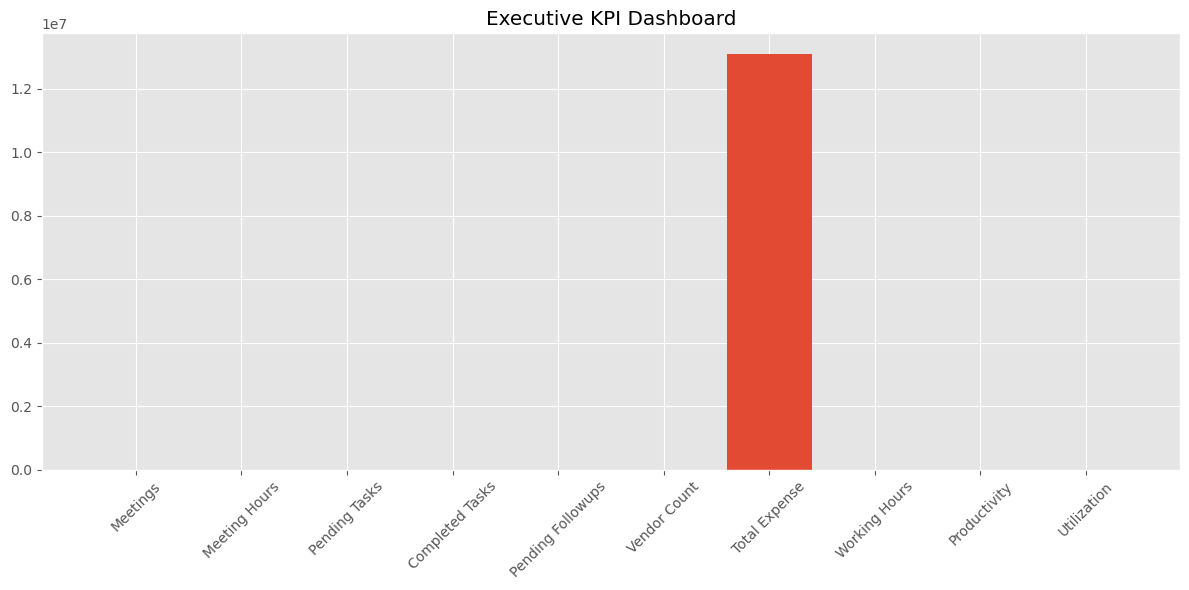

In [8]:
plt.figure(figsize=(12,6))

plt.bar(kpi["Metric"],kpi["Value"])

plt.xticks(rotation=45)

plt.title("Executive KPI Dashboard")

plt.tight_layout()

plt.savefig(os.path.join(charts_folder,"Executive_KPI.png"))

plt.show()

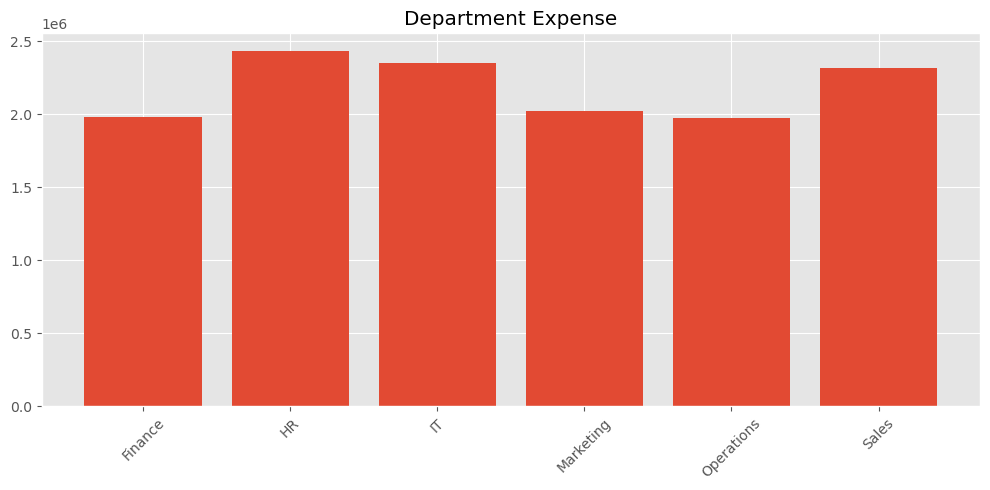

In [9]:
department=expense_df.groupby("Department")["Amount"].sum()

plt.figure(figsize=(10,5))

plt.bar(department.index,department.values)

plt.xticks(rotation=45)

plt.title("Department Expense")

plt.tight_layout()

plt.savefig(os.path.join(charts_folder,"Department_Expense_MIS.png"))

plt.show()

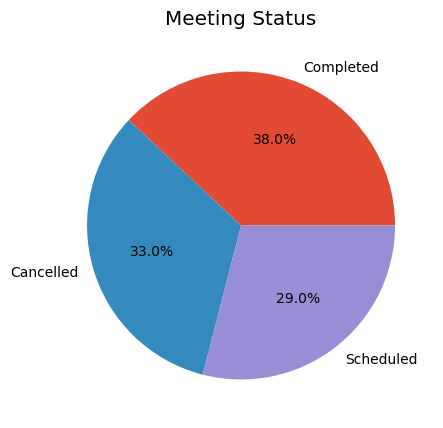

In [10]:
status=meeting_df["Status"].value_counts()

plt.figure(figsize=(8,5))

plt.pie(status.values,
        labels=status.index,
        autopct="%1.1f%%")

plt.title("Meeting Status")

plt.savefig(os.path.join(charts_folder,"Meeting_Status_MIS.png"))

plt.show()

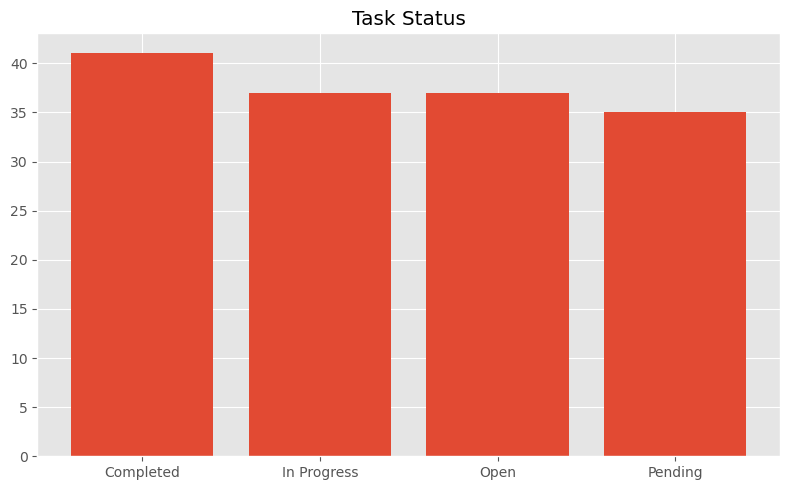

In [11]:
task=task_df["Status"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(task.index,task.values)

plt.title("Task Status")

plt.tight_layout()

plt.savefig(os.path.join(charts_folder,"Task_Status_MIS.png"))

plt.show()

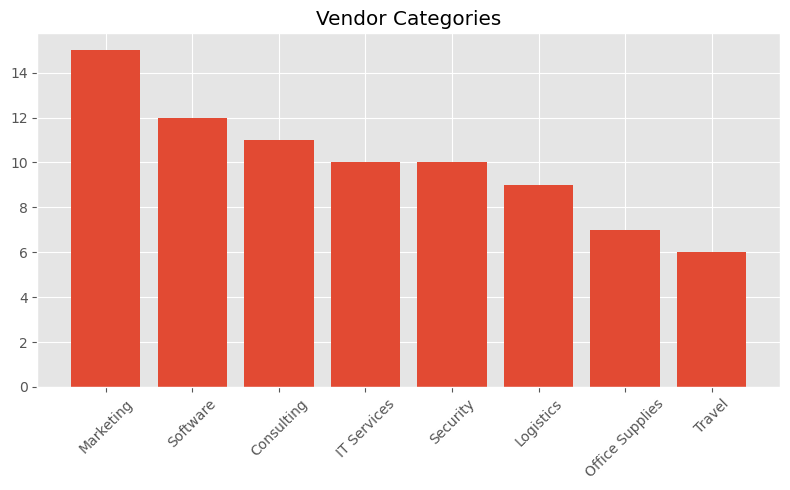

In [12]:
vendor=vendor_df["Category"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(vendor.index,vendor.values)

plt.xticks(rotation=45)

plt.title("Vendor Categories")

plt.tight_layout()

plt.savefig(os.path.join(charts_folder,"Vendor_Category_MIS.png"))

plt.show()

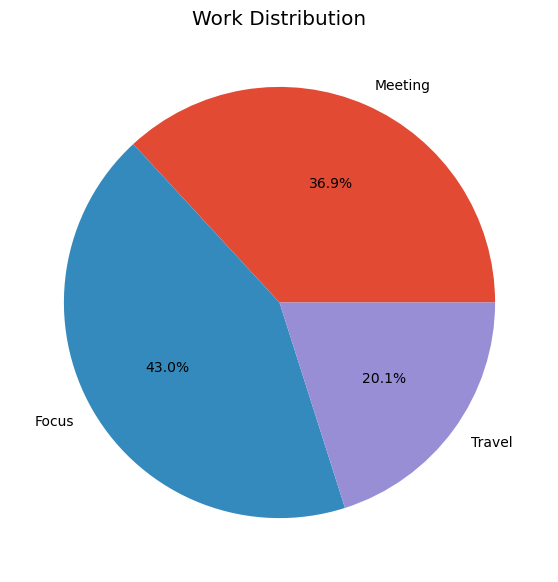

In [13]:
values=[
calendar_df["Meeting_Hours"].sum(),
calendar_df["Focus_Hours"].sum(),
calendar_df["Travel_Hours"].sum()
]

labels=[
"Meeting",
"Focus",
"Travel"
]

plt.figure(figsize=(7,7))

plt.pie(values,
        labels=labels,
        autopct="%1.1f%%")

plt.title("Work Distribution")

plt.savefig(os.path.join(charts_folder,"Work_Distribution.png"))

plt.show()

In [14]:
print("="*60)

print("BUSINESS INSIGHTS")

print("="*60)

print(f"• Total Meetings Conducted : {total_meetings}")

print(f"• Pending Tasks : {pending_tasks}")

print(f"• Pending Follow-ups : {pending_followups}")

print(f"• Vendors Managed : {vendor_count}")

print(f"• Total Spending : ₹{total_expense:,.2f}")

print(f"• Productivity Score : {productivity}%")

print(f"• Resource Utilization : {utilization}%")

BUSINESS INSIGHTS
• Total Meetings Conducted : 100
• Pending Tasks : 35
• Pending Follow-ups : 36
• Vendors Managed : 80
• Total Spending : ₹13,090,267.25
• Productivity Score : 43.05%
• Resource Utilization : 100.24%


In [15]:
kpi.to_excel(

os.path.join(

reports_folder,

"Executive_MIS_Report.xlsx"

),

index=False

)

print("Executive MIS Report Saved Successfully")

Executive MIS Report Saved Successfully


In [16]:
print("="*70)

print("EXECUTIVE MIS DASHBOARD COMPLETED")

print("="*70)

print(f"Reports Saved : {reports_folder}")

print(f"Charts Saved  : {charts_folder}")

print("="*70)

EXECUTIVE MIS DASHBOARD COMPLETED
Reports Saved : Executive_Assistant_Business_Dashboard\reports
Charts Saved  : Executive_Assistant_Business_Dashboard\charts
